In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import pickle
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from code_location_interview.assets.magenta_interview.transformation import summarize_customer_interactions


In [40]:
def load_artifact(targ_file:str):
    targ_path = os.path.join(dir,targ_file)

    with open(targ_path,'rb') as fp:
        test_artifact = pickle.load(fp)

    return test_artifact

In [41]:
# Each time that you initialize Dagster a new temporary folder is created.
# For the porpuse of this exercise we will save data in that temporary folder.
# Substitute tmp*** with your folder (you can fin it in this repo).
dir = "../tmpyj3_9y9n/storage/"

`core_data`

| Feature Name           | Description                                                  |
|------------------------|--------------------------------------------------------------|
| rating_account_id      | Unique identifier for the contract account                    |
| customer_id            | Unique identifier for the customer                           |
| age                    | Age of the customer                                          |
| contract_lifetime_days | Total duration of the customer contract in days              |
| remaining_binding_days | Number of days left in the contract binding period - usual binding period is 2 years        |
| has_special_offer      | Indicates if the customer has a special offer      |
| is_magenta1_customer   | Indicates if the customer is part of the Magenta1 program - fedelty program    |
| available_gb           | Amount of mobile data included in the current tariff         |
| gross_mrc              | Gross monthly recurring charge (in euros)                    |
| smartphone_brand       | Brand of the customer’s smartphone                           |
| has_done_upselling     | Whether the customer has already done an upsell in the last 3 years      |


In [42]:
core_data = load_artifact("core_data")
core_data

,rating_account_id,customer_id,age,contract_lifetime_days,remaining_binding_days,has_special_offer,is_magenta1_customer,available_gb,gross_mrc,smartphone_brand,has_done_upselling
0,333820,5.785921,35,316,267,0,0,0,14.29,iPhone,0
1,301065,4.560229,41,980,517,0,0,20,66.02,iPhone,0
2,858306,1.108349,40,105,-92,0,0,50,63.37,iPhone,0
3,580112,3.510127,47,373,-144,1,0,30,12.96,Samsung,0
4,372754,3.296895,40,935,107,0,0,20,70.00,iPhone,0
...,...,...,...,...,...,...,...,...,...,...,...
99995,591839,2.690421,93,1674,-233,1,1,20,31.53,Huawei,0
99996,238439,1.116779,91,1497,187,0,0,0,8.98,Huawei,0
99997,548489,1.565276,91,1782,-639,0,0,40,30.20,Samsung,0
99998,932962,1.324967,84,1772,167,0,0,0,16.94,Samsung,0


`usage_info`

| Feature Name           | Description                                                  |
|------------------------|--------------------------------------------------------------|
| rating_account_id      | Unique identifier for the contract account                    |
| billed_period_month_d  | Billing period (monthly)                                     |
| has_used_roaming       | Indicates if roaming was used during the period            |
| used_gb                | Amount of mobile data used in the billing period (in GB)     |


In [43]:
usage_info = load_artifact("usage_info")
usage_info

,rating_account_id,billed_period_month_d,has_used_roaming,used_gb
0,333820,2024-04-01,1,0.4
1,333820,2024-05-01,0,0.0
2,333820,2024-06-01,1,0.8
3,333820,2024-07-01,1,0.6
4,301065,2024-04-01,0,0.1
...,...,...,...,...
399995,932962,2024-07-01,1,64.0
399996,371058,2024-04-01,1,66.4
399997,371058,2024-05-01,0,40.5
399998,371058,2024-06-01,0,63.0


`customer_interactions`

| Feature Name   | Description                                                              |
|----------------|--------------------------------------------------------------------------|
| customer_id    | Unique identifier for the customer                                       |
| type_subtype   | Category and subtype of the interaction (e.g., tariff change, billing)   |
| n              | Number of interactions of this type in the last 6 months                                |
| days_since_last| Number of days since the last interaction of this type                   |


In [44]:
customer_interactions = load_artifact("customer_interactions")
customer_interactions

,customer_id,type_subtype,n,days_since_last
0,3.209902,rechnungsanfragen,3,148
1,2.418624,produkte&services-tarifdetails,2,89
2,1.560206,produkte&services-tarifdetails,1,168
3,5.598783,prolongation,2,78
4,3.751902,produkte&services-tarifwechsel,3,106
...,...,...,...,...
63104,3.980142,prolongation,2,1
63105,3.980142,produkte&services-tarifwechsel,1,41
63106,1.945920,produkte&services-tarifwechsel,3,41
63107,1.945920,produkte&services-tarifdetails,1,72


## 0. Check data types

In [45]:
print(f"core_data dtypes:\n{core_data.dtypes}")
print("""\ncustomer_id has float like values but is of object type, whether or not that is an issue depends on the data type of customer_id in the other tables.
available_gb is also object type but should be numeric if numeric operations are needed (e.g. relative amount of data used = used_gb / available_gb).
smartphone_brand is object type but should be categorical.
""")

print(f"usage_info dtypes:\n{usage_info.dtypes}")
print("billed_period_month_date should be datetime type.\n")

print(f"customer_interactions dtypes:\n{customer_interactions.dtypes}")
print("customer_id is of object type as in table core_data so neither needs to be changed. type_subtype should be categorical.\n")

core_data['available_gb'] = pd.to_numeric(core_data['available_gb'], errors='coerce')
core_data['smartphone_brand'] = core_data['smartphone_brand'].astype('category')

usage_info['billed_period_month_d'] = pd.to_datetime(
    usage_info['billed_period_month_d'], errors='coerce'
)

customer_interactions['type_subtype'] = customer_interactions['type_subtype'].astype('category')

core_data dtypes:
rating_account_id           int64
customer_id                object
age                         int64
contract_lifetime_days      int64
remaining_binding_days      int64
has_special_offer           int64
is_magenta1_customer        int64
available_gb               object
gross_mrc                 float64
smartphone_brand           object
has_done_upselling          int64
dtype: object

customer_id has float like values but is of object type, whether or not that is an issue depends on the data type of customer_id in the other tables.
available_gb is also object type but should be numeric if numeric operations are needed (e.g. relative amount of data used = used_gb / available_gb).
smartphone_brand is object type but should be categorical.

usage_info dtypes:
rating_account_id          int64
billed_period_month_d     object
has_used_roaming           int64
used_gb                  float64
dtype: object
billed_period_month_date should be datetime type.

customer_interact

## 1. Understanding the Data

Before I explore the data in depth, I want to understand the logic of the data and make assumptions about it, whenever more information about the data is required to understand it fully or the randomness of the data introduces problems (in a real world context I would ask someone to clarify, instead of making assumptions).

Since every column in each dataset has already been described above, their individual meaning is clear. I want to focus on investigating implicit assumptions I have about the data due to the data structure and the column descriptions.

1. A contract account can have only one customer, one customer can have multiple contracts (e.g. multiple phones in the household)

2. The age of the customer is the same for each customer id across the dataset, since there is no time variable (e.g. they were 30 in 2024 and 29 in 2023)

3. There is no variable indicating whether someone is upselling or going to upsell in the future in a given period (only for past periods). After asking a team member at magenta whether has_done_upselling is the target variable on which the training should be based upon I will use it as such. For a reals use case I would try to construct a label, that indicates whether someone will upsell in the future and use recent upsells as a feature instead. A recent upsell might be an indicator that a person will likely not upgrade their plan again in the near future regardless of marketing activities. Predicting future upsells can reveal customers, which are likely to use a more expensive plan and can be nudged to upgrade their plan with the appropriate marketing activities.

In [46]:
# 1. Check assumption: one contract account -> one customer, one customer -> multiple contracts
contracts_per_customer = core_data.groupby('customer_id')['rating_account_id'].nunique()
customers_per_contract = core_data.groupby('rating_account_id')['customer_id'].nunique()

print("Contracts per customer (should often be >1 if customers can have multiple contracts):")
print(contracts_per_customer.describe())
print("\nCustomers per contract (should always be 1):")
print(customers_per_contract.value_counts())

# 2. Check assumption: same age for each customer_id
age_variation = core_data.groupby('customer_id')['age'].nunique()
inconsistent_ages = age_variation[age_variation > 1]
print(f"\nNumber of customers with inconsistent ages: {len(inconsistent_ages)}")
if len(inconsistent_ages) > 0:
    print("This assumption is violated. The age seems to be different for each contract, not each customer. Whether or not this column will be used for inference will be discussed later.")

Contracts per customer (should often be >1 if customers can have multiple contracts):
count    58652.000000
mean         1.704972
std          0.899180
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: rating_account_id, dtype: float64

Customers per contract (should always be 1):
customer_id
1    100000
Name: count, dtype: int64

Number of customers with inconsistent ages: 27501
This assumption is violated. The age seems to be different for each contract, not each customer. Whether or not this column will be used for inference will be discussed later.


Before merging tables, check how the foreign keys match up (e.g. are there customer_ids in usage_info that are not in core_data?).

In [47]:
# Check if every rating_account_id in core_data is present in usage_info and vice versa
core_rating_ids = set(core_data['rating_account_id'].unique())
usage_rating_ids = set(usage_info['rating_account_id'].unique())

missing_in_usage = core_rating_ids - usage_rating_ids
missing_in_core = usage_rating_ids - core_rating_ids

print(f"rating_account_id in core_data but missing in usage_info: {len(missing_in_usage)}")
print(f"rating_account_id in usage_info but missing in core_data: {len(missing_in_core)}")

if missing_in_usage:
    print("Example missing in usage_info:", list(missing_in_usage)[:5])
if missing_in_core:
    print("Example missing in core_data:", list(missing_in_core)[:5])


# Check if every customer_id in core_data is present in customer_interactions and vice versa
core_customer_ids = set(core_data['customer_id'].unique())
interact_customer_ids = set(customer_interactions['customer_id'].unique())

missing_in_interactions = core_customer_ids - interact_customer_ids
missing_in_core_customers = interact_customer_ids - core_customer_ids

print(f"\ncustomer_id in core_data but missing in customer_interactions: {len(missing_in_interactions)}")
print(f"customer_id in customer_interactions but missing in core_data: {len(missing_in_core_customers)}")

if missing_in_interactions:
    print("Example missing in customer_interactions:", list(missing_in_interactions)[:5])
if missing_in_core_customers:
    print("Example missing in core_data:", list(missing_in_core_customers)[:5])


rating_account_id in core_data but missing in usage_info: 0
rating_account_id in usage_info but missing in core_data: 0

customer_id in core_data but missing in customer_interactions: 29320
customer_id in customer_interactions but missing in core_data: 12785
Example missing in customer_interactions: ['2.866626', '1.436717', '1.599732', '1.454231', '4.976003']
Example missing in core_data: ['4.109904', '2.838462', '4.422480', '4.150214', '5.316770']


core_data and usage info have the same rating_account_ids. There are customers without interactions (I will assume they have 0 interactions) and interactions of customers that are not present in the core data. Since the interaction data on itself is not very informative I will disregard this data, by making a left merge from core_data to customer_interactions as soon as a merge is required and fill missing data with 0, where it makes sense.

## Data Exploration

In [65]:
core_data["has_remaining_binding_days"] = (core_data["remaining_binding_days"] > 0).astype('int')
core_data.drop(columns=["rating_account_id"]).describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,100000,58652,5.263527,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,43.88362,13.754758,18.0,36.0,43.0,49.0,100.0
contract_lifetime_days,100000.0,NaN,NaN,NaN,779.34754,489.135285,7.0,373.0,733.0,1095.25,1825.0
remaining_binding_days,100000.0,NaN,NaN,NaN,1.53014,344.773318,-730.0,-231.0,1.0,234.0,730.0
has_special_offer,100000.0,NaN,NaN,NaN,0.29928,0.457945,0.0,0.0,0.0,1.0,1.0
is_magenta1_customer,100000.0,NaN,NaN,NaN,0.30212,0.459179,0.0,0.0,0.0,1.0,1.0
available_gb,85724.0,NaN,NaN,NaN,24.815804,17.103591,0.0,10.0,20.0,40.0,50.0
gross_mrc,100000.0,NaN,NaN,NaN,37.466828,19.154573,5.0,20.92,36.84,54.08,70.0
smartphone_brand,100000,5,iPhone,39885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_done_upselling,100000.0,NaN,NaN,NaN,0.06937,0.254084,0.0,0.0,0.0,0.0,1.0


Quick Insights:
- available_gb only variable with missing values. Can be left in data for now if we chose an algorithm that can handle missing data (e.g. XGBoost), since imputing it with 0 might be wrong if it is missing at random.
- has_done_upselling is imbalanced (only around 7% positives). This might need to be handled if we try to use a classifier later on, to help the model identify "rare" positive cases. 

In [66]:
customer_interactions.drop(columns=["customer_id"]).describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type_subtype,63109,4,prolongation,15849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,63109.0,NaN,NaN,NaN,1.924718,1.403762,1.0,1.0,1.0,2.0,10.0
days_since_last,63109.0,NaN,NaN,NaN,89.960703,52.353926,0.0,45.0,90.0,135.0,180.0


In [67]:
unique_types = customer_interactions["type_subtype"].unique()
print(f"There are {len(unique_types)} unique interaction type/subtype combinations:")
for item in unique_types:
    print(f" - {item}")

There are 4 unique interaction type/subtype combinations:
 - rechnungsanfragen
 - produkte&services-tarifdetails
 - prolongation
 - produkte&services-tarifwechsel


To use the interaction counts and days_since_last interaction data per type later on as features, it makes sense to pivot the data to have a row for each customer and a column for each type as well as the sum of the interactions and the days_since_last of the most recent interaction.

In [68]:
customer_interactions_pivot = summarize_customer_interactions(customer_interactions)

In [69]:
customer_interactions_pivot.describe(include="all").T

count       mean  \
                    type_subtype                                         
days_since_last     produkte&services-tarifdetails  15737.0  90.187774   
                    produkte&services-tarifwechsel  15709.0  90.187027   
                    prolongation                    15849.0  90.336362   
                    rechnungsanfragen               15814.0  89.133426   
n                   produkte&services-tarifdetails  42117.0   0.723200   
                    produkte&services-tarifwechsel  42117.0   0.722582   
                    prolongation                    42117.0   0.715079   
                    rechnungsanfragen               42117.0   0.723176   
min_days_since_last                                 42117.0  76.463851   
sum_n                                               42117.0   2.884037   

                                                          std  min   25%  \
                    type_subtype                                           
days_since_last     produkte&services-tarifdetails  52.307632  0.0  45.0   
                    produkte&services-tarifwechsel  52.918698  0.0  44.0   
                    prolongation                    52.195515  0.0  45.0   
                    rechnungsanfragen               51.989283  0.0  44.0   
n                   produkte&services-tarifdetails   1.280540  0.0   0.0   
                    produkte&services-tarifwechsel   1.271661  0.0   0.0   
                    prolongation                     1.241200  0.0   0.0   
                    rechnungsanfragen                1.275472  0.0   0.0   
min_days_since_last                                 51.153174  0.0  32.0   
sum_n                                                2.150444  1.0   1.0   

                                                     50%    75%    max  
                    type_subtype                                        
days_since_last     produkte&services-tarifdetails  90.0  136.0  180.0  
                    produkte&services-tarifwechsel  90.0  137.0  180.0  
                    prolongation                    91.0  136.0  180.0  
                    rechnungsanfragen               89.0  134.0  180.0  
n                   produkte&services-tarifdetails   0.0    1.0   10.0  
                    produkte&services-tarifwechsel   0.0    1.0   10.0  
                    prolongation                     0.0    1.0   10.0  
                    rechnungsanfragen                0.0    1.0   10.0  
min_days_since_last                                 70.0  118.0  180.0  
sum_n                                                2.0    4.0   27.0

Quick Insights:
- Every column within days_since_last and n is pretty much identically distributed so probably generated from the same distribution

In [70]:
usage_info.drop(columns="rating_account_id").describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
billed_period_month_d,400000,2024-05-16 12:00:00,2024-04-01 00:00:00,2024-04-23 12:00:00,2024-05-16 12:00:00,2024-06-08 12:00:00,2024-07-01 00:00:00,NaN
has_used_roaming,400000.0,0.29949,0.0,0.0,0.0,1.0,1.0,0.458035
used_gb,400000.0,13.991169,0.0,1.0,5.0,15.0,70.0,18.644576


In [71]:
core_data_usage_info_merged = core_data.merge(
    usage_info,
    on='rating_account_id',
    how='left',
)
core_data_usage_info_merged["leftover_data_gb"] = core_data_usage_info_merged["available_gb"] - core_data_usage_info_merged["used_gb"]

Quick Insights:
- ~30% of contract months have used roaming 

It would be interesting to see how much of the available data (from core_data) was left at the end of the month and see if it depends on whether a person has used roaming or not, since on vacation you might use more data than usually. A person using roaming could therefore be a potential target for an upselling campaign if they use more data than usual.

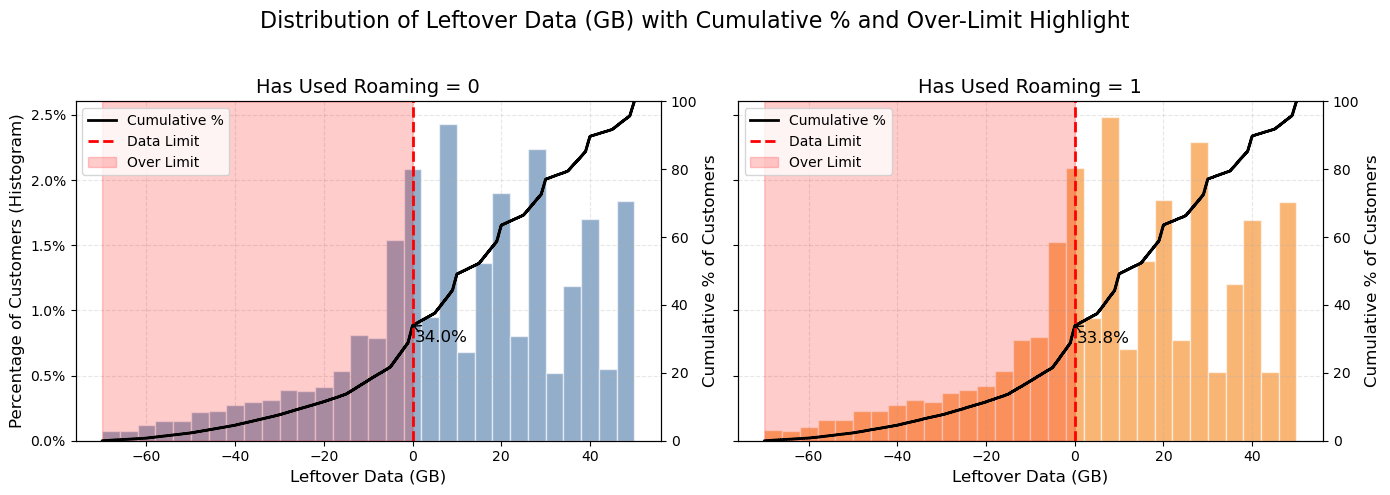

In [72]:
data_limit = 0  # leftover_data_gb = 0 is exactly at the limit

# Unique values for has_used_roaming
roaming_values = sorted(core_data_usage_info_merged["has_used_roaming"].dropna().unique())

fig, axes = plt.subplots(1, len(roaming_values), figsize=(14, 5), sharey=True)

for ax, value in zip(axes, roaming_values):
    subset = core_data_usage_info_merged[core_data_usage_info_merged["has_used_roaming"] == value]
    data = subset["leftover_data_gb"].dropna()
    
    # Histogram as percentage
    n, bins, patches = ax.hist(
        data,
        bins=30,
        color="#4C78A8" if not value else "#F58518",
        edgecolor="white",
        alpha=0.6,
        density=True
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
    
    # Cumulative distribution
    sorted_data = np.sort(data)
    cum_percentage = np.arange(1, len(sorted_data)+1) / len(sorted_data) * 100
    
    ax2 = ax.twinx()
    ax2.plot(sorted_data, cum_percentage, color='black', linestyle='-', linewidth=2, label='Cumulative %')
    ax2.axvline(data_limit, color='red', linestyle='--', linewidth=2, label='Data Limit')
    
    # Highlight customers OVER the limit (negative leftover) on the left
    ax2.fill_betweenx(
        cum_percentage,
        x1=sorted_data.min(),
        x2=data_limit,
        color='red',
        alpha=0.2,
        label='Over Limit'
    )
    
    # Annotate cumulative % at data limit
    idx = np.searchsorted(sorted_data, data_limit, side='right') - 1
    if idx >= 0:
        cum_val_at_limit = cum_percentage[idx]
        ax2.annotate(
            f"{cum_val_at_limit:.1f}%",
            xy=(data_limit, cum_val_at_limit),
            xytext=(data_limit + 0.5, cum_val_at_limit - 5),
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            fontsize=12,
            color='black'
        )
    
    ax.set_title(f"Has Used Roaming = {value}", fontsize=14)
    ax.set_xlabel("Leftover Data (GB)", fontsize=12)
    ax.grid(alpha=0.3, linestyle="--")
    
    ax2.set_ylabel("Cumulative % of Customers", fontsize=12)
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')

axes[0].set_ylabel("Percentage of Customers (Histogram)", fontsize=12)
fig.suptitle("Distribution of Leftover Data (GB) with Cumulative % and Over-Limit Highlight", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


The data seems to be coming from the same distribution and does not depend on whether someone used roaming or not. 
Furthermore 34% of contract months have used up more than the available data on their plan. These could be potential candidates for an upgrade of their data contract.

Since the usage data has 4 entries by rating_account_id (for 4 months of usage), we need to either 

1. pivot the data to result in 1 data point per rating_account_id or 
2. construct aggregate measures from the available data. 

The first option would result in an excessive amount of features, especially if there was data for more than 4 months. So I will continue with option 2 and aggregate the data.

In [73]:
aggregated_usage_info = core_data_usage_info_merged.groupby("rating_account_id").agg(
    {
        "leftover_data_gb": ["mean", "std", "min", "max"],
        "used_gb": ["mean", "std", "min", "max"],
        "has_used_roaming": "sum",  
    }
)

In [74]:
# Flatten multi-level columns for pivot table
customer_interactions_pivot.columns = [
    "_".join([str(c) for c in col if c]) for col in customer_interactions_pivot.columns
]

# Flatten multi-level columns for usage info
aggregated_usage_info.columns = [
    "_".join([str(c) for c in col if c]) for col in aggregated_usage_info.columns
]

# Merge the data
merged_data = core_data.merge(
    customer_interactions_pivot, 
    on="customer_id", 
    how="left"
).merge(
    aggregated_usage_info,
    on="rating_account_id",
    how="left"
)
merged_data["sum_n"] = merged_data["sum_n"].fillna(0)

In [75]:
profile_report = ProfileReport(merged_data.drop(columns=["customer_id", "rating_account_id"]), minimal=True)
profile_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:00<00:00, 51.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

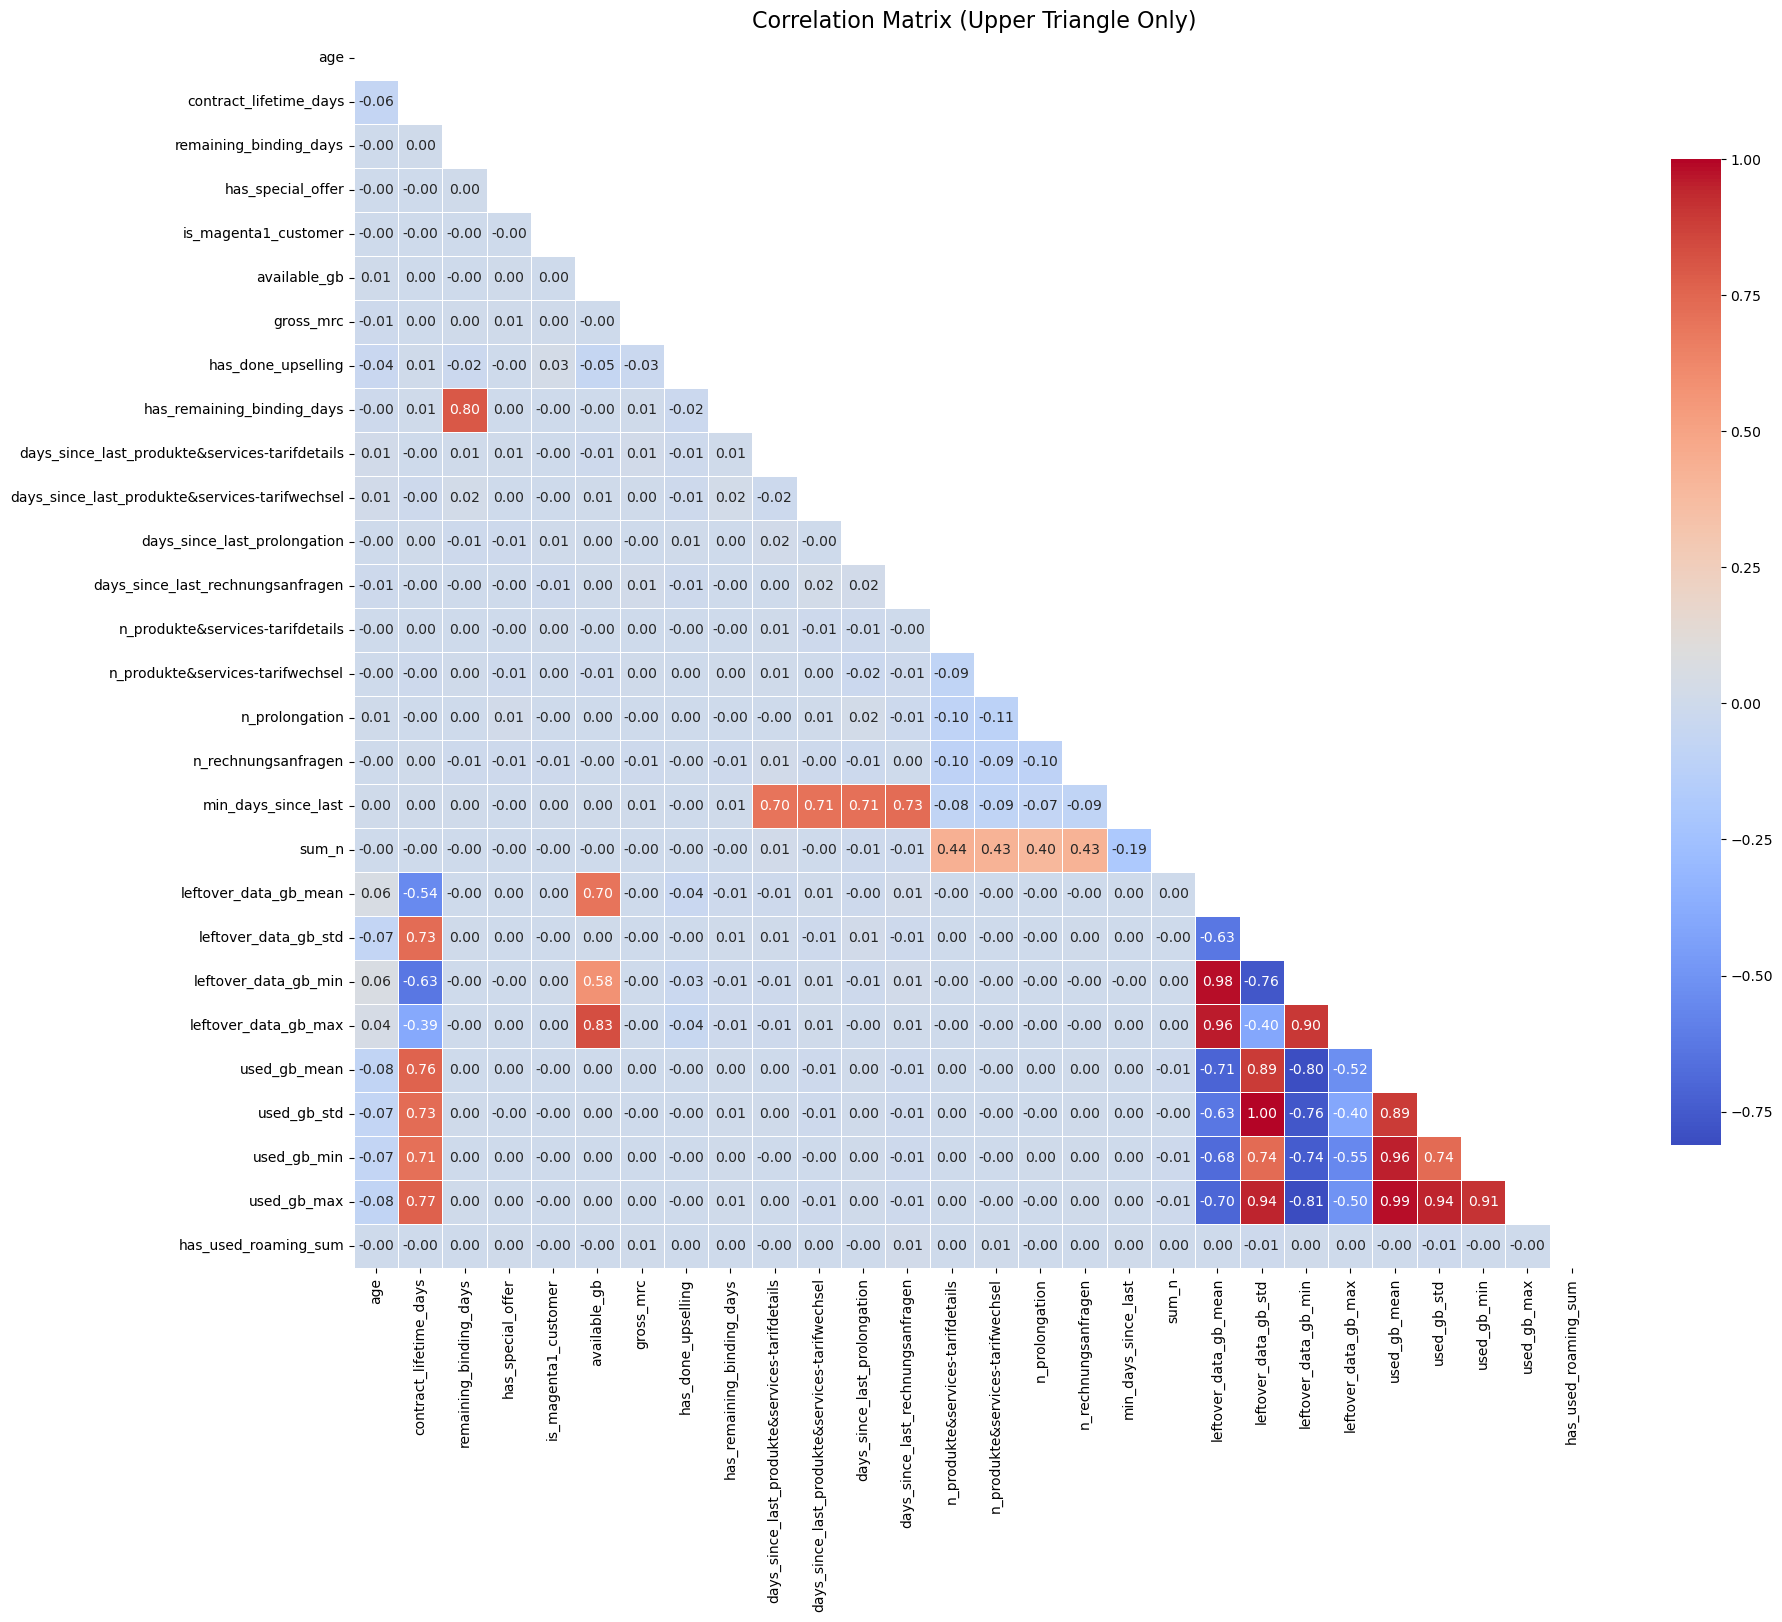

In [76]:
# Select numeric columns, exclude any column with 'id'
numeric_data = merged_data.select_dtypes(include="number").drop(
    columns=[col for col in merged_data.columns if "id" in col.lower()],
    errors="ignore"
)

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(20, 16))

# Draw the heatmap with the mask
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar_kws={"shrink": 0.8},
    linewidths=0.5
)

plt.title("Correlation Matrix (Upper Triangle Only)", fontsize=16)
plt.show()


Correlation Matrix Analysis:
While nothing seems to be correlated to the target variable has_done_upselling there are some correlations present between the features themselves.

- not surprisingly the used_gb and leftover_gb metrics are highly correlated since they are mathematically dependent on each other. The same holds true for the interaction metrics with their aggregated counterparts sum_n and min_days_since_last as well as the has_remaining_binding_days column and its counterpart remaining_binding_days.
- furthermore there seems to be a correlation between the contract_lifetime_days and the used_gb / leftover_data_gb columns. People with higher contract lifetimes tend to use more gb and have less leftover gb at the end of the month. 